<a href="https://colab.research.google.com/github/ogrisel/notebooks/blob/master/poly_reg_array_api_vs_tabicl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU support in scikit-learn with the Python array API and comparison with TabICLv2

## Example of a complex non-linear regression pipeline

### Some boring setup

At the time of writing, this notebook requires experimental features only available in the developer version of scikit-learn:

In [2]:
# %pip uninstall -q -y sklearn-compat
# %pip install -q -U --pre --extra-index https://pypi.anaconda.org/scientific-python-nightly-wheels/simple scikit-learn

Let's enable the Array API support in SciPy and scikit-learn. See the scikit-learn documentation for more details:

https://scikit-learn.org/dev/modules/array_api.html

In [3]:
import os
import sklearn
import warnings

os.environ["SCIPY_ARRAY_API"] = "1"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
sklearn.set_config(array_api_dispatch=True)

warnings.filterwarnings("ignore", category=RuntimeWarning)  # matmul divide by zero on macOS...
warnings.filterwarnings("ignore", category=UserWarning)  # n_components > n_samples

### Our (Synthetic) Data Genering Process

Let's define a low dimensional (2D) regression problem. We use a 2D feature space is nice to be able to plot the prediction functions.

In [4]:
import numpy as np
import torch


def true_mean(X):
    return np.sin(X[:, 0] * 2) * np.cos(X[:, 1]) ** 4


def true_std(X):
    return 0.3 * np.cos(X[:, 1]) ** 6 + 0.1


def make_data(n_samples=int(1e5), seed=0):
    rng = np.random.default_rng(seed=seed)
    X = rng.uniform(low=-3, high=3, size=(n_samples, 2))
    y = rng.normal(loc=true_mean(X), scale=true_std(X))
    return X.astype(np.float32), y.astype(np.float32)


X, y = make_data()


In [10]:
try:
    import dpnp
    import dpctl
    use_dnpnp = len(dpctl.get_devices(device_type="gpu")) >= 1
except ImportError:
    dpnp = None
    use_dnpnp = False

if use_dnpnp:
    gpu_module = dpnp
    gpu_device = "gpu"
else:
    gpu_module = torch
    if torch.backends.cuda.is_built():
        gpu_device = "cuda"
    elif torch.backends.mps.is_built():
        gpu_device = "mps"
    elif torch.xpu.is_available():
        gpu_device = "xpu"
    else:
        print("No GPU device found, falling back to CPU...")
        gpu_device = "cpu"

gpu_module.__name__, gpu_device

('torch', 'mps')


The **non-linear interactions** of the features makes the regression problem more complex: a simple linear regression model would not be well-specified for this task.

The feature dependent variance of the target variable makes this problem an **heteroscedastic** regression problem. This would be important to keep in mind if we were to model prediction uncertainty but we will leave that aside for this notebook and only focus on modeling the conditional mean of the target.

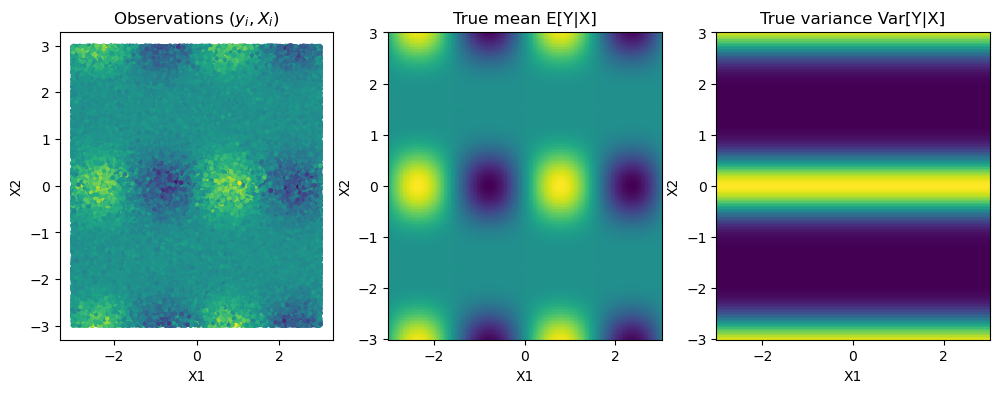

In [11]:
import matplotlib.pyplot as plt

x1 = np.linspace(-3, 3, 200).astype(np.float32)
x2 = np.linspace(-3, 3, 200).astype(np.float32)
X1, X2 = np.meshgrid(x1, x2)


def to_numpy(array):
    if torch.is_tensor(array):
        return array.cpu().numpy()
    elif dpnp is not None and isinstance(array, dpnp.ndarray):
        return array.asnumpy()
    else:
        return array


def mesh_call(ax, func, X1, X2):
    mesh_preds = to_numpy(func(np.c_[X1.ravel(), X2.ravel()]))
    ax.pcolormesh(X1, X2, mesh_preds.reshape(*X1.shape))


fig, axs = plt.subplots(ncols=3, figsize=(12, 4))
axs[0].scatter(X[:, 0], X[:, 1], c=y, s=5)
axs[0].set(title="Observations $(y_i, X_i)$", xlabel="X1", ylabel="X2");
mesh_call(axs[1], true_mean, X1, X2)
axs[1].set(title="True mean E[Y|X]", xlabel="X1", ylabel="X2")
mesh_call(axs[2], true_std, X1, X2)
_ = axs[2].set(title="True variance Var[Y|X]", xlabel="X1", ylabel="X2")

This is a medium-size machine learning problem. The total dataset contains 100k observations in a 2D space:

In [12]:
print(f"dataset size: {(X.nbytes + y.nbytes) / 1e6:.1f} MB")

dataset size: 1.2 MB


Let's estimate the Bayes error rate for this data generating process:

In [13]:
from sklearn.metrics import r2_score

r2_dgp = round(r2_score(y, true_mean(X)), 4)
r2_dgp

0.7438

 The majority (but not all) of the variability of the target `y` can be explained by the input features in `X`.

**The R2 score of the predictions computed by the "perfect"  `true_mean` function is far from 1.0, but this is expected!** The data generating process is not a deterministic function of `X`: observations are sampled from a random variable with non-zero variance.

 This means that some of the variability of `y` cannot be entirely explained by the input features in `X`. For real data generating process, this happens when the observations in `y` are influenced by unmeasured factors that are independent of the input features. This is almost always the case in practical machine learning applications.

### Polynomial regression pipelines with scikit-learn

In the following we will attempt to compose scikit-learn building block to train a model that estimates this mean function as accurately as possible from the available data points.

We first consider a polynomial regression pipeline fit on the CPU using the default NumPy & SciPy-based implementations that comes with scikit-learn:

In [14]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import RidgeCV
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import cross_validate


poly_reg_numpy_cpu = make_pipeline(
    SplineTransformer(n_knots=5),
    Nystroem(kernel="poly", degree=2, n_components=300, random_state=0),
    RidgeCV(alphas=np.logspace(-6, 6, 13)),
)
poly_reg_numpy_cpu

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('splinetransformer', ...), ('nystroem', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_knots n_knots: int, default=5Number of knots of the splines if `knots` equals one of{'uniform', 'quantile'}. Must be larger or equal 2. Ignored if `knots`is array-like.",5
,"degree degree: int, default=3The polynomial degree of the spline basis. Must be a non-negativeinteger.",3
,"knots knots: {'uniform', 'quantile'} or array-like of shape (n_knots, n_features), default='uniform'Set knot positions such that first knot <= features <= last knot.- If 'uniform', `n_knots` number of knots are distributed uniformly from min to max values of the features.- If 'quantile', they are distributed uniformly along the quantiles of the features.- If an array-like is given, it directly specifies the sorted knot positions including the boundary knots. Note that, internally, `degree` number of knots are added before the first knot, the same after the last knot.",'uniform'
,"extrapolation extrapolation: {'error', 'constant', 'linear', 'continue', 'periodic'}, default='constant'If 'error', values outside the min and max values of the trainingfeatures raises a `ValueError`. If 'constant', the value of thesplines at minimum and maximum value of the features is used asconstant extrapolation. If 'linear', a linear extrapolation is used.If 'continue', the splines are extrapolated as is, i.e. option`extrapolate=True` in :class:`scipy.interpolate.BSpline`. If'periodic', periodic splines with a periodicity equal to the distancebetween the first and last knot are used. Periodic splines enforceequal function values and derivatives at the first and last knot.For example, this makes it possible to avoid introducing an arbitraryjump between Dec 31st and Jan 1st in spline features derived from anaturally periodic ""day-of-year"" input feature. In this case it isrecommended to manually set the knot values to control the period.",'constant'
,"include_bias include_bias: bool, default=TrueIf False, then the last spline element inside the data rangeof a feature is dropped. As B-splines sum to one over the spline basisfunctions for each data point, they implicitly include a bias term,i.e. a column of ones. It acts as

In [20]:
%%time
poly_reg_cv_results_numpy_cpu = pd.DataFrame(cross_validate(poly_reg_numpy_cpu, X, y, cv=5))
poly_reg_cv_results_numpy_cpu.round(3)

CPU times: user 4.44 s, sys: 1.48 s, total: 5.92 s
Wall time: 5.96 s


,fit_time,score_time,test_score
0,1.200,0.012,0.639
1,1.196,0.011,0.634
2,1.138,0.011,0.633
3,1.213,0.011,0.627
4,1.157,0.011,0.635


Fitting and evaluating the pipeline 5 times on the 2 CPU cores takes around 30 s on the basic free Google Colab VM and around 10 s with more powerful CPUs.

Note that this pipeline has many hyper-parameters to adjust. **Tweaking hyperparameters interactively with a 30 s long iteration cycle is not feasible: the data scientist will often loose their focus**.

Conducting a systematic hyper-parameter tuning sweap would require more CPUs on a beefier dedicated machine and would also break the interactive user experience.

### Enabling GPU computation with PyTorch

Let's instead adapt the pipeline to move the last two steps (which happen to be the linear-algebra heavy steps) to the GPU with the help of PyTorch:

In [16]:
from functools import partial
from sklearn.preprocessing import FunctionTransformer

poly_reg_torch_gpu = make_pipeline(
    SplineTransformer(n_knots=5),
    FunctionTransformer(partial(gpu_module.asarray, device=gpu_device)),  # <- new step
    Nystroem(kernel="poly", degree=2, n_components=300, random_state=0),
    RidgeCV(alphas=np.logspace(-6, 6, 13)),
).fit(X, y)
poly_reg_torch_gpu

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('splinetransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"n_knots n_knots: int, default=5Number of knots of the splines if `knots` equals one of{'uniform', 'quantile'}. Must be larger or equal 2. Ignored if `knots`is array-like.",5
,"degree degree: int, default=3The polynomial degree of the spline basis. Must be a non-negativeinteger.",3
,"knots knots: {'uniform', 'quantile'} or array-like of shape (n_knots, n_features), default='uniform'Set knot positions such that first knot <= features <= last knot.- If 'uniform', `n_knots` number of knots are distributed uniformly from min to max values of the features.- If 'quantile', they are distributed uniformly along the quantiles of the features.- If an array-like is given, it directly specifies the sorted knot positions including the boundary knots. Note that, internally, `degree` number of knots are added before the first knot, the same after the last knot.",'uniform'
,"extrapolation extrapolation: {'error', 'constant', 'linear', 'continue', 'periodic'}, default='constant'If 'error', values outside the min and max values of the trainingfeatures raises a `ValueError`. If 'constant', the value of thesplines at minimum and maximum value of the features is used asconstant extrapolation. If 'linear', a linear extrapolation is used.If 'continue', the splines are extrapolated as is, i.e. option`extrapolate=True` in :class:`scipy.interpolate.BSpline`. If'periodic', periodic splines with a periodicity equal to the distancebetween the first and last knot are used. Periodic splines enforceequal function values and derivatives at the first and last knot.For example, this makes it possible to avoid introducing an arbitraryjump between Dec 31st and Jan 1st in spline features derived from anaturally periodic ""day-of-year"" input feature. In this case it isrecommended to manually set the knot values to control the period.",'constant'
,"include_bias include_bias: bool, default=TrueIf Fa

In [17]:
%%time
poly_reg_cv_results_torch_gpu = pd.DataFrame(cross_validate(
    poly_reg_torch_gpu, X, y, cv=5, error_score="raise"
))
poly_reg_cv_results_torch_gpu.round(3)

CPU times: user 382 ms, sys: 83.1 ms, total: 465 ms
Wall time: 1.76 s


,fit_time,score_time,test_score
0,0.356,0.086,0.661
1,0.300,0.023,0.657
2,0.311,0.023,0.649
3,0.323,0.015,0.654
4,0.297,0.023,0.656


In [18]:
fit_gpu_speed_up = (
    poly_reg_cv_results_numpy_cpu["fit_time"].mean()
    / poly_reg_cv_results_torch_gpu["fit_time"].mean()
)
score_gpu_speed_up = (
    poly_reg_cv_results_numpy_cpu["score_time"].mean()
    / poly_reg_cv_results_torch_gpu["score_time"].mean()
)
print(f"Fit time GPU speed-up: {fit_gpu_speed_up:.1f}x")
print(f"Predict time GPU speed-up {score_gpu_speed_up:.1f}x")

Fit time GPU speed-up: 3.8x
Predict time GPU speed-up 0.3x


This is much faster than with NumPy on the CPU!

But the predictive quality should not be significantly impacted:

In [21]:
poly_reg_cv_results_torch_gpu["test_score"].mean().round(3).item()

0.655

This is quite far from the R2 score of the true data generating process which is:

In [22]:
r2_dgp

0.7438

Let's qualitatively check the learned prediction function of the models trained for the each iteration of this cross-validation:

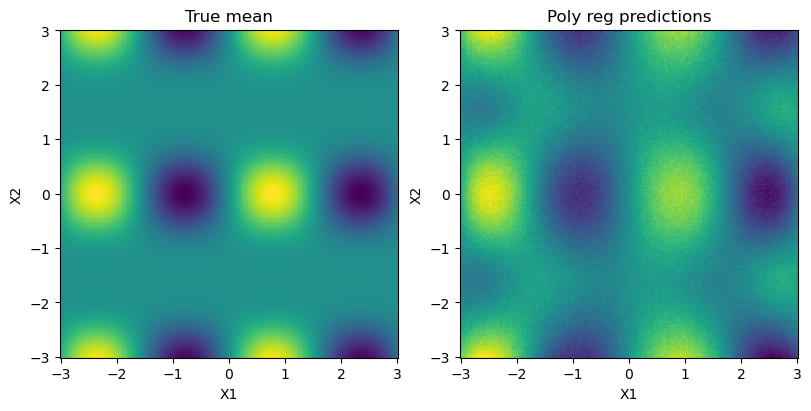

In [23]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), constrained_layout=True)
mesh_call(axs[0], true_mean, X1, X2)
axs[0].set(title="True mean", xlabel="X1", ylabel="X2")
mesh_call(axs[1], poly_reg_torch_gpu.predict, X1, X2)
axs[1].set(title="Poly reg predictions", xlabel="X1", ylabel="X2");

This looks ok but still far from perfect...

### Custom code to compute reliability curves for mean and quantile regressors

In [24]:
def _compute_reliability_curve(df, n_bins, functional):
    """Compute mean predicted and observed quantile per bin.

    The bins are sorted by mean predicted value."""
    df_bin = pd.qcut(df["y_predicted"], q=n_bins)

    df_binned = df.assign(bin=df_bin)
    agg_df = df_binned.groupby("bin", observed=True).agg(
        y_predicted=("y_predicted", "mean"),
        y_observed=("y_observed", functional),
    )
    agg_df = agg_df.sort_values("y_predicted").reset_index(drop=True)
    return agg_df["y_predicted"].values, agg_df["y_observed"].values


def plot_reliability_diagram(
    y_observed,
    y_predicted,
    quantile_level=None,
    n_bins="auto",
    min_n_bins=5,
    max_n_bins=30,
    n_bootstrap=100,
    confidence_level=0.95,
    model_name=None,
    random_state=None,
    ax=None,
):
    """Plot reliability diagram with bootstrap confidence intervals."""
    rng = np.random.default_rng(random_state)
    n_samples = len(y_observed)
    if quantile_level is not None:
        functional = partial(np.quantile, q=quantile_level)
    else:
        functional = "mean"

    if n_bins == "auto":
        n_bins_sturges = int(np.ceil(np.log2(n_samples) + 1))
        n_bins = max(min_n_bins, min(max_n_bins, n_bins_sturges))

    # Original reliability curve (main estimate)
    df = pd.DataFrame({"y_observed": y_observed, "y_predicted": y_predicted})
    x_orig, y_orig = _compute_reliability_curve(df, n_bins, functional)

    # Full bootstrap: compute entire reliability curve for each resample to
    # assess a confidence interval for the reliability curve itself.
    bootstrap_x = np.full((n_bootstrap, n_bins), np.nan)
    bootstrap_y = np.full((n_bootstrap, n_bins), np.nan)
    for bootstrap_idx in range(n_bootstrap):
        idx = rng.integers(0, n_samples, size=n_samples)
        df_boot = df.iloc[idx].reset_index(drop=True)
        x_boot, y_boot = _compute_reliability_curve(df_boot, n_bins, functional)
        bootstrap_x[bootstrap_idx] = x_boot
        bootstrap_y[bootstrap_idx] = y_boot

    # Use the mean x across bootstraps as reference (handles variable bin centers).
    x_ref = np.nanmean(bootstrap_x, axis=0)
    alpha = 1 - confidence_level
    y_lower = np.nanquantile(bootstrap_y, alpha / 2, axis=0)
    y_upper = np.nanquantile(bootstrap_y, 1 - alpha / 2, axis=0)

    # Plot the reliability curve and the confidence interval.
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

    range_min = min(x_orig.min(), y_orig.min())
    range_max = max(x_orig.max(), y_orig.max())
    offset = (range_max - range_min) * 0.05
    extended_range = [range_min - offset, range_max + offset]
    ax.plot(
        extended_range,
        extended_range,
        color="black",
        linestyle="--",
        label="Perfect reliability",
    )
    ax.fill_between(
        x_ref,
        y_lower,
        y_upper,
        alpha=0.2,
        color="C0",
        label=f"{100 * confidence_level:.0f}% bootstrap CI",
    )
    if model_name is None:
        model_name = "Model"
    ax.plot(x_orig, y_orig, color="C0", lw=2, label=model_name)
    ax.set_xlim(extended_range)
    ax.set_ylim(extended_range)
    if quantile_level is not None:
        ax.set_title(f"Reliability diagram for {quantile_level}-quantile regression")
        ax.set_xlabel(f"Predicted {quantile_level}-quantile")
        ax.set_ylabel(f"Observed {quantile_level}-quantile")
    else:
        ax.set_title("Reliability diagram for mean regression")
        ax.set_xlabel("Predicted mean")
        ax.set_ylabel("Observed mean")
    ax.legend(loc="upper left")


### Reliability of our polynomial regressor with default hyper-parameters

In [ ]:
X_test, y_test = make_data(n_samples=int(3e4), seed=2)

plot_reliability_diagram(y_test, to_numpy(poly_reg_torch_gpu.predict(X_test)))

We observe that **the reliabilty curve of this first model is off the diagonal**: it either over- or under-estimate the true value of $E[y|X]$  almost everywhere.

From the above performance measures and plots we can conclude that our polynomial pipeline is both qualitatitively and quantitative **far from optimal**.


### Tuning the polynomial regression pipeline on the GPU

But since fitting this pipeline is now much faster, let's try to tune the hyperparameters:

In [ ]:
%%time
from sklearn.model_selection import RandomizedSearchCV


param_grid = dict(
    splinetransformer__n_knots=range(3, 30),
    nystroem__kernel=["poly", "rbf"],
    nystroem__degree=[2, 3, 4, 5],
    nystroem__gamma=np.logspace(-6, 6, 100),
    nystroem__n_components=[50, 100, 200, 500],
)

search_cv = RandomizedSearchCV(
    poly_reg_torch_gpu,
    param_grid,
    n_iter=15,
    random_state=0,
)
search_cv.fit(X, y)

In [ ]:
search_cv.best_score_.round(4).item()

In [ ]:
r2_dgp

The cross-validation score of the best model is very close to the Bayes optimal score computed from our knowledge of the data-generating process!

Let's qualitatively compare our mean estimate to the ground truth of the data generating process.

In [ ]:
tuned_poly_reg = search_cv.best_estimator_

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
mesh_call(axs[0], true_mean, X1, X2)
axs[0].set(title="True mean", xlabel="X1", ylabel="X2")
mesh_call(axs[1], search_cv.predict, X1, X2)
axs[1].set(title="Tuned pipeline predictions", xlabel="X1", ylabel="X2");

In [ ]:
plot_reliability_diagram(y_test, to_numpy(tuned_poly_reg.predict(X_test)))

We see a **very good match**: it's hard to visually identify any defect once the hyparameters have been tuned.

Thanks to **GPU** acceleration, we can **tune the hyperparameters** a complex pipeline to get a very good model **in the time it would take to run a single cross-validation** on the Google Colab CPU.

More importantly, the training speed is fast enough to **avoid disrupting the model development flow** of the data scientist editing the Google Colab notebook **interactively**.


Let's have a look at the optimal hyper-parameter combinations:

In [ ]:
search_cv.best_params_

In [ ]:
search_cv.best_estimator_[-1].alpha_

For completeness here are the other hyperparameters of the leading models in the search:

In [ ]:
pd.DataFrame(
    search_cv.cv_results_
).sort_values("mean_test_score", ascending=False).head().round(3)